# EXPT NO: 2 - Comparative Study of Activation Functions and Optimization Algorithms

This notebook contains the implementation and analysis for the Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning.

## Setup and Imports
We begin by importing the necessary libraries and creating a directory for our plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import os

# Create directory for plots
os.makedirs('plots', exist_ok=True)

## PART A: VISUALIZATION OF ACTIVATION FUNCTIONS
In this section, we implement and plot the Sigmoid, Tanh, and ReLU activation functions to compare their behavior.

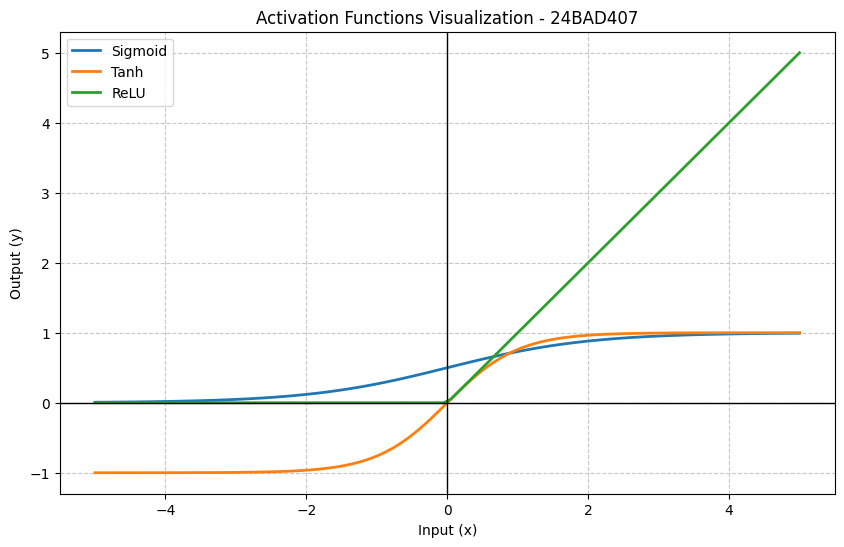

In [10]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def plot_activation_functions():
    x = np.linspace(-5, 5, 100)

    plt.figure(figsize=(10, 6))
    plt.plot(x, sigmoid(x), label='Sigmoid', linewidth=2)
    plt.plot(x, tanh(x), label='Tanh', linewidth=2)
    plt.plot(x, relu(x), label='ReLU', linewidth=2)

    plt.title('Activation Functions Visualization - 24BAD407')
    plt.xlabel('Input (x)')
    plt.ylabel('Output (y)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.show()

plot_activation_functions()

## Data Preparation
We use the MNIST dataset for our performance comparisons.

In [11]:
def load_data():
    mnist = tf.keras.datasets.mnist
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train, x_test = x_train / 255.0, x_test / 255.0
    return x_train, y_train, x_test, y_test

def create_model(activation='relu', optimizer='adam'):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation=activation),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

x_train, y_train, x_test, y_test = load_data()

## PART B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS
We train identical ANN architectures using Sigmoid, Tanh, and ReLU to record and compare their performance.

Training with sigmoid...
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8694 - loss: 0.5191 - val_accuracy: 0.9334 - val_loss: 0.2297
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9423 - loss: 0.2001 - val_accuracy: 0.9521 - val_loss: 0.1702
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9582 - loss: 0.1421 - val_accuracy: 0.9608 - val_loss: 0.1342
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9684 - loss: 0.1077 - val_accuracy: 0.9668 - val_loss: 0.1113
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9749 - loss: 0.0834 - val_accuracy: 0.9680 - val_loss: 0.1065
Training with tanh...
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9157 - loss: 0.2930 - val_accuracy: 0.9514 - val_loss: 0.1690
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9596 - loss: 0.1357 - val_accuracy: 0.9629 - val_loss: 0.1248
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6

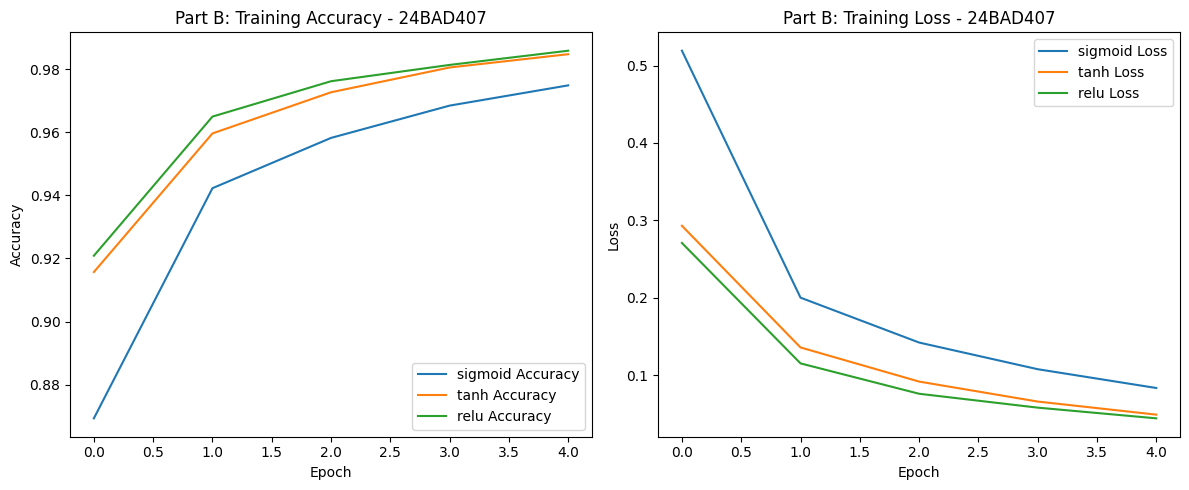

In [13]:
activations = ['sigmoid', 'tanh', 'relu']
results_b = {}

for act in activations:
    print(f"Training with {act}...")
    model = create_model(activation=act, optimizer='adam')
    history = model.fit(x_train, y_train, epochs=5, validation_split=0.2, verbose=1)
    results_b[act] = history.history

# Plot Part B Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for act in activations:
    plt.plot(results_b[act]['accuracy'], label=f'{act} Accuracy')
plt.title('Part B: Training Accuracy - 24BAD407')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for act in activations:
    plt.plot(results_b[act]['loss'], label=f'{act} Loss')
plt.title('Part B: Training Loss - 24BAD407')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## PART C: COMPARISON OF OPTIMIZATION ALGORITHMS
We train the same ANN using different optimization algorithms: SGD, Momentum, RMSProp, and Adam.

Training with SGD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8165 - loss: 0.6873 - val_accuracy: 0.9074 - val_loss: 0.3359
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9082 - loss: 0.3202 - val_accuracy: 0.9219 - val_loss: 0.2705
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9254 - loss: 0.2638 - val_accuracy: 0.9323 - val_loss: 0.2351
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9359 - loss: 0.2265 - val_accuracy: 0.9441 - val_loss: 0.2054
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9426 - loss: 0.1991 - val_accuracy: 0.9463 - val_loss: 0.1911
Training with Momentum...
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9060 - loss: 0.3164 - val_accuracy: 0.9516 - val_loss: 0.1600
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9599 - loss: 0.1328 - val_accuracy: 0.9632 - val_loss: 0.1241
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9720

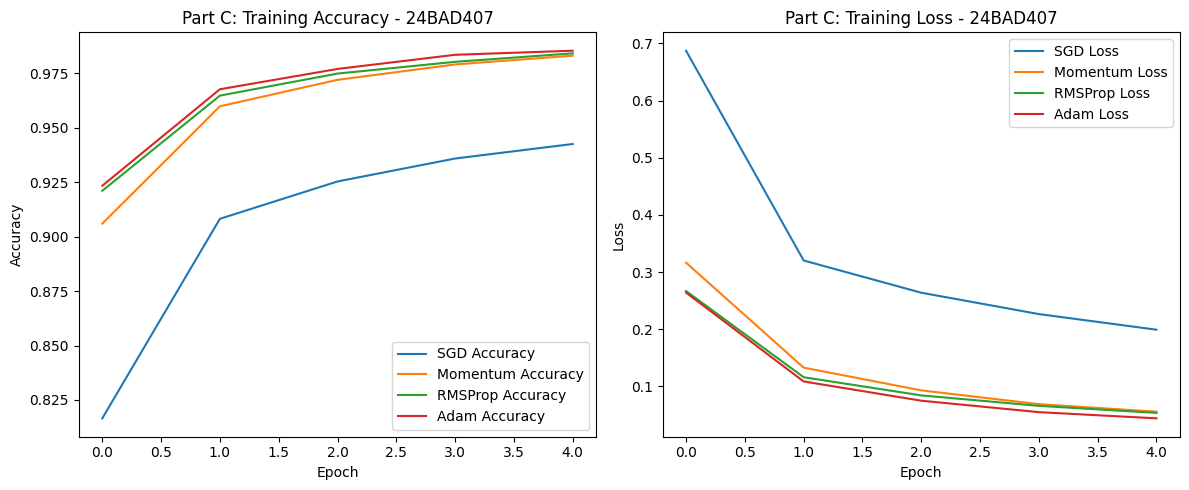

In [12]:
optimizer_names = ['SGD', 'Momentum', 'RMSProp', 'Adam']
optimizers_list = [
    optimizers.SGD(learning_rate=0.01),
    optimizers.SGD(learning_rate=0.01, momentum=0.9),
    optimizers.RMSprop(learning_rate=0.001),
    optimizers.Adam(learning_rate=0.001)
]
results_c = {}

for name, opt in zip(optimizer_names, optimizers_list):
    print(f"Training with {name}...")
    model = create_model(activation='relu', optimizer=opt)
    history = model.fit(x_train, y_train, epochs=5, validation_split=0.2, verbose=1)
    results_c[name] = history.history

# Plot Part C Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name in optimizer_names:
    plt.plot(results_c[name]['accuracy'], label=f'{name} Accuracy')
plt.title('Part C: Training Accuracy - 24BAD407')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for name in optimizer_names:
    plt.plot(results_c[name]['loss'], label=f'{name} Loss')
plt.title('Part C: Training Loss - 24BAD407')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# PART-D : Google **Drive** mounting and Github actions

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os
import shutil

folder_path = "/content/drive/MyDrive/DL_Lab_Files"
os.makedirs(folder_path, exist_ok=True)

source_file = "/content/EX 1- Simple ANN for Regression & Classificat.docx"
destination_file = os.path.join(folder_path, "EX 1- Simple ANN for Regression & Classificat.docx")

shutil.copy2(source_file, destination_file)

print("✅ Folder created (if needed) and file saved successfully!")

print("\nFiles in the folder:")
print(os.listdir(folder_path))

✅ Folder created (if needed) and file saved successfully!

Files in the folder:
['EX 1- Simple ANN for Regression & Classificat.docx']
